In [2]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *

%matplotlib widget

In [98]:
project_name = "syn"
condition = "debug"
data = "test1"
switch_epoch = 10000
checkpoint_epoch = 0

n_samples_test = 1
show_results_fusion = True
fusion_attr_weight = 1.0
noise = 0.0

experiment_name = get_experiment_name(condition, data, switch_epoch)
cat_names=CAT_NAMES

training_params = get_training_params(project_name, experiment_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

global_workspace = get_global_workspace(project_name, experiment_name, epoch=checkpoint_epoch)
data_module = get_data_module(project_name,  experiment_name)
test_samples = get_data_samples(data_module, n_samples_test, noise=  noise, split= "test")
data_translated = get_data_translated(global_workspace, test_samples, n_samples_test)


Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/debug_test1_switch_10000/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/debug_test1_switch_10000/checkpoints/last.ckpt


In [99]:
params = global_workspace.gw_mod.gw_decoders['attr'].named_parameters()

for name, param in params: 
        print(f"--- Layer: {name} ---")
        print(f"Mean: {param.data.mean().item():.4f}")
        print(f"Std:  {param.data.std().item():.4f}")
        print(f"Max:  {param.data.max().item():.4f}")
        # Vérifier s'il y a des NaN (très important !)
        if torch.isnan(param.data).any():
            print("⚠️ WARNING: NaN detected in weights!")


--- Layer: decoder.0.weight ---
Mean: -0.0002
Std:  0.0886
Max:  0.3625
--- Layer: decoder.0.bias ---
Mean: 0.0000
Std:  0.0000
Max:  0.0000
--- Layer: decoder.2.weight ---
Mean: -0.0003
Std:  0.0883
Max:  0.4033
--- Layer: decoder.2.bias ---
Mean: 0.0000
Std:  0.0000
Max:  0.0000
--- Layer: decoder_categories.0.weight ---
Mean: 0.0509
Std:  0.8390
Max:  3.3489
--- Layer: decoder_categories.0.bias ---
Mean: 0.0000
Std:  0.0000
Max:  0.0000
--- Layer: decoder_attributes.0.weight ---
Mean: 0.0205
Std:  0.6504
Max:  2.5940
--- Layer: decoder_attributes.0.bias ---
Mean: 0.0000
Std:  0.0000
Max:  0.0000


In [46]:
masks = get_mask_from_shapes(data_translated["train_images"])


In [47]:
masks_diff = get_mask_from_shapes_diff(data_translated["train_images"])

In [48]:
masks_diff_np = (masks_diff.detach().cpu().numpy() > 0.5).astype(np.uint8)
masks_orig_np = np.array(masks).astype(np.uint8)

if masks_diff_np.ndim == 4: # Si (B, 1, H, W)
    masks_diff_np = masks_diff_np.squeeze(1)

In [49]:
masks_diff_np[0]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [50]:
def calculate_iou(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    if union == 0: return 1.0
    return intersection / union

ious = [calculate_iou(masks_orig_np[i], masks_diff_np[i]) for i in range(len(masks_orig_np))]
mean_iou = np.mean(ious)

print(f"✅ Score IoU moyen : {mean_iou:.4f}")
if mean_iou > 0.95:
    print("Résultat : Les fonctions sont quasi-équivalentes.")
else:
    print("Résultat : Il y a des divergences (vérifiez la température ou le seuil).")

✅ Score IoU moyen : 0.7791
Résultat : Il y a des divergences (vérifiez la température ou le seuil).


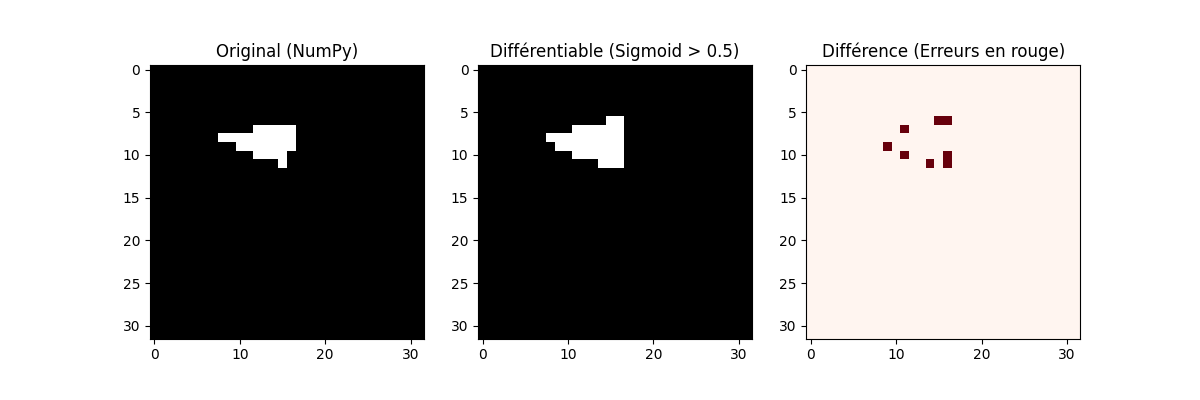

In [51]:
def plot_comparison(idx):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.title("Original (NumPy)")
    plt.imshow(masks_orig_np[idx], cmap='gray')
    
    plt.subplot(1, 3, 2)
    plt.title("Différentiable (Sigmoid > 0.5)")
    plt.imshow(masks_diff_np[idx], cmap='gray')
    
    plt.subplot(1, 3, 3)
    plt.title("Différence (Erreurs en rouge)")
    # Affiche les pixels où les deux masques ne sont pas d'accord
    diff = np.abs(masks_orig_np[idx].astype(float) - masks_diff_np[idx].astype(float))
    plt.imshow(diff, cmap='Reds')
    
    plt.show()

# Tester sur la première image du batch
plot_comparison(0)

In [52]:
data_translated["train_images"]

tensor([[[[8.2183e-26, 3.5244e-31, 1.2483e-34,  ..., 6.1933e-23,
           1.2980e-18, 4.2589e-11],
          [2.5677e-31, 1.8362e-38, 0.0000e+00,  ..., 9.1919e-25,
           9.7469e-23, 1.5815e-13],
          [2.2394e-31, 9.7073e-37, 1.6448e-35,  ..., 2.3307e-25,
           9.0004e-25, 5.1473e-15],
          ...,
          [3.3304e-22, 3.5114e-29, 3.3555e-35,  ..., 0.0000e+00,
           0.0000e+00, 9.9740e-21],
          [3.8021e-17, 5.2409e-22, 9.0025e-26,  ..., 0.0000e+00,
           1.5235e-28, 1.1665e-15],
          [1.3520e-10, 1.2004e-13, 2.1684e-14,  ..., 4.8290e-25,
           4.7800e-18, 4.8541e-10]],

         [[4.1858e-25, 2.4937e-30, 1.0992e-33,  ..., 5.4568e-22,
           3.9759e-18, 5.1240e-11],
          [2.7000e-30, 1.4753e-37, 2.9854e-39,  ..., 1.0220e-23,
           4.9342e-22, 3.2147e-13],
          [3.1689e-30, 1.1304e-35, 1.4426e-34,  ..., 9.0488e-24,
           9.3768e-24, 1.3853e-14],
          ...,
          [3.6384e-21, 6.7689e-28, 3.4325e-34,  ..., 0.0000

In [53]:
data_translated["images_decoded"][0]

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])

In [54]:
def dice_loss(pred, target, smooth=0.1):
    """
    Computes the Dice Loss for binary segmentation.
    Args:
        pred: Tensor of predictions (batch_size, 1, H, W).
        target: Tensor of ground truth (batch_size, 1, H, W).
        smooth: Smoothing factor to avoid division by zero.
    Returns:
        Scalar Dice Loss.
    """
    # Apply sigmoid to convert logits to probabilities
    
    # Calculate intersection and union
    intersection = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    
    # Compute Dice Coefficient
    dice = (2. * intersection + smooth) / (union + smooth)
    
    # Return Dice Loss
    return 1 - dice


In [55]:
def get_mask_from_shapes_diff(images: torch.Tensor, temperature: float = 100.0) -> torch.Tensor:
    """
    Version différentiable de l'extraction de masque avec normalisation [0, 1].
    """
    # 1. Travailler sur une copie pour éviter toute modification in-place de l'original
    x = images.clone()

    # 2. Normalisation [0, 1] par batch (ou globale)
    # On calcule le min et le max pour chaque image du batch (dim H et W)
    # .view(B, C, -1) permet d'isoler tous les pixels par canal
    min_val = x.view(x.size(0), x.size(1), -1).min(dim=2)[0].view(-1, x.size(1), 1, 1)
    max_val = x.view(x.size(0), x.size(1), -1).max(dim=2)[0].view(-1, x.size(1), 1, 1)
    
    # On normalise en évitant la division par zéro (eps = 1e-8)
    # x_norm = (x - min) / (max - min)
    grayscale = (x - min_val) / (max_val - min_val + 1e-8)

    # 3. Conversion en niveaux de gris si RGB
    if grayscale.shape[1] == 3:
        grayscale = grayscale.mean(dim=1, keepdim=True)

    # 4. Sigmoid "Hard" : Approximation du seuillage
    # On centre le seuil (threshold). Comme on est maintenant en [0, 1], 
    # un seuil à 0.1 est raisonnable pour ignorer le bruit de fond noir.
    threshold = 0.1
    masks = torch.sigmoid((grayscale - threshold) * temperature)
    
    return masks


In [56]:
target = get_mask_from_shapes_diff(data_translated["train_images"])
pred = get_mask_from_shapes_diff(data_translated["images_decoded"])

In [57]:
target[0].min()

tensor(4.5398e-05)

In [58]:
dice_loss(pred, target)

tensor([[0.9776],
        [0.9232],
        [0.4161],
        [0.9989],
        [0.2665],
        [0.7344],
        [0.6267],
        [0.9639],
        [0.6503],
        [0.9989],
        [0.9301],
        [0.5543],
        [0.6960],
        [0.9988],
        [0.6560],
        [0.8303],
        [0.9296],
        [0.9192],
        [0.6317],
        [0.8742],
        [0.9301],
        [0.5862],
        [0.6405],
        [0.9989],
        [0.8151],
        [0.5762],
        [0.4699],
        [0.7210],
        [0.9883],
        [0.7683],
        [0.9543],
        [0.9987],
        [0.9989],
        [0.6534],
        [0.8878],
        [0.9989],
        [0.9989],
        [0.4015],
        [0.9993],
        [0.7281],
        [0.9987],
        [0.8492],
        [0.9469],
        [0.8685],
        [0.9991],
        [0.3958],
        [0.7646],
        [0.9159],
        [0.6666],
        [0.9992],
        [0.9787],
        [0.9994],
        [0.5403],
        [0.9428],
        [0.9208],
        [0

In [59]:
pred[0]

tensor([[[4.5398e-05, 4.5398e-05, 4.5398e-05,  ..., 4.5398e-05,
          4.5398e-05, 4.5398e-05],
         [4.5398e-05, 4.5398e-05, 4.5398e-05,  ..., 4.5398e-05,
          4.5398e-05, 4.5398e-05],
         [4.5398e-05, 4.5398e-05, 4.5398e-05,  ..., 4.5398e-05,
          4.5398e-05, 4.5398e-05],
         ...,
         [4.5398e-05, 4.5398e-05, 4.5398e-05,  ..., 4.5398e-05,
          4.5398e-05, 4.5398e-05],
         [4.5398e-05, 4.5398e-05, 4.5398e-05,  ..., 4.5398e-05,
          4.5398e-05, 4.5398e-05],
         [4.5398e-05, 4.5398e-05, 4.5398e-05,  ..., 4.5398e-05,
          4.5398e-05, 4.5398e-05]]])

In [60]:
dice_loss(pred, target)

tensor([[0.9776],
        [0.9232],
        [0.4161],
        [0.9989],
        [0.2665],
        [0.7344],
        [0.6267],
        [0.9639],
        [0.6503],
        [0.9989],
        [0.9301],
        [0.5543],
        [0.6960],
        [0.9988],
        [0.6560],
        [0.8303],
        [0.9296],
        [0.9192],
        [0.6317],
        [0.8742],
        [0.9301],
        [0.5862],
        [0.6405],
        [0.9989],
        [0.8151],
        [0.5762],
        [0.4699],
        [0.7210],
        [0.9883],
        [0.7683],
        [0.9543],
        [0.9987],
        [0.9989],
        [0.6534],
        [0.8878],
        [0.9989],
        [0.9989],
        [0.4015],
        [0.9993],
        [0.7281],
        [0.9987],
        [0.8492],
        [0.9469],
        [0.8685],
        [0.9991],
        [0.3958],
        [0.7646],
        [0.9159],
        [0.6666],
        [0.9992],
        [0.9787],
        [0.9994],
        [0.5403],
        [0.9428],
        [0.9208],
        [0

In [61]:
pred.size()

torch.Size([1000, 1, 32, 32])

In [62]:
masks_diff_np

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [63]:
target_img_np = (target.detach().cpu().numpy() > 0.5).astype(np.uint8)
pred_img_np = (pred.detach().cpu().numpy() > 0.5).astype(np.uint8)

if target_img_np.ndim == 4: # Si (B, 1, H, W)
    target_img_np = target_img_np.squeeze(1)

if pred_img_np.ndim == 4: # Si (B, 1, H, W)
    pred_img_np = pred_img_np.squeeze(1)

In [64]:
target_img_np[0]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [65]:
masks_diff_np[0]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

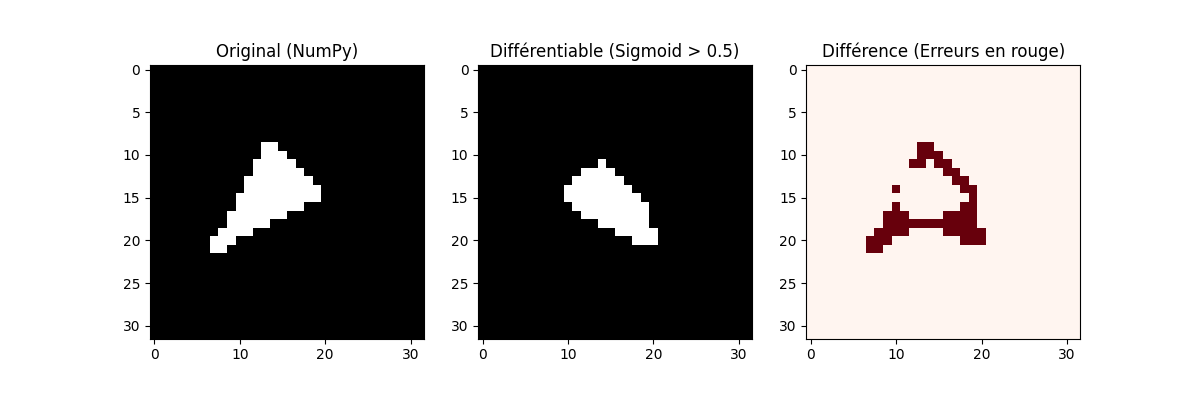

In [66]:
def plot_comparison(idx):

    target_img = target_img_np
    pred_img = pred_img_np
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.title("Original (NumPy)")
    plt.imshow(target_img[idx], cmap='gray')
    
    plt.subplot(1, 3, 2)
    plt.title("Différentiable (Sigmoid > 0.5)")
    plt.imshow(pred_img[idx], cmap='gray')
    
    plt.subplot(1, 3, 3)
    plt.title("Différence (Erreurs en rouge)")
    # Affiche les pixels où les deux masques ne sont pas d'accord
    diff = np.abs(target_img[idx].astype(float) - pred_img[idx].astype(float))
    plt.imshow(diff, cmap='Reds')
    
    plt.show()

# Tester sur la première image du batch
plot_comparison(2)

In [67]:
def get_centroid(mask: torch.Tensor):
    """
    Calcule les coordonnées (x, y) du centre de masse d'un masque.
    mask: Tensor de forme (B, 1, H, W)
    """
    B, C, H, W = mask.shape
    device = mask.device
    
    # Création des grilles de coordonnées normalisées entre 0 et 1
    # grid_x: [[0, 1, 2...], [0, 1, 2...]]
    grid_y, grid_x = torch.meshgrid(
        torch.linspace(0, 1, H, device=device),
        torch.linspace(0, 1, W, device=device),
        indexing='ij'
    )
    
    # Somme des intensités pour la normalisation (la "masse" totale)
    # On ajoute un epsilon pour éviter la division par zéro si le masque est noir
    total_mass = mask.sum(dim=(2, 3)) + 1e-8
    
    # Calcul du centre de masse pondéré par l'intensité des pixels
    pos_x = (mask * grid_x).sum(dim=(2, 3)) / total_mass
    pos_y = (mask * grid_y).sum(dim=(2, 3)) / total_mass
    
    # Retourne un tenseur (B, 2) contenant les coordonnées [x, y]
    return torch.cat([pos_x, pos_y], dim=1)

In [68]:
def area_loss(m_pred, m_orig):
    """
    Force la surface totale (nombre de pixels activés) à être identique.
    m_pred, m_orig: (B, 1, H, W)
    """
    # Somme des intensités des pixels (approximation de l'aire)
    area_pred = m_pred.sum(dim=(1, 2, 3))
    area_orig = m_orig.sum(dim=(1, 2, 3))
    
    # On utilise L1 pour une pénalité stable et linéaire
    return F.l1_loss(area_pred, area_orig) / (32 * 32)

In [69]:
def centroid_loss(m_pred, m_orig):
    """Calcule la distance MSE entre les centres de masse."""
    center_pred = get_centroid(m_pred)
    center_orig = get_centroid(m_orig)
    return F.mse_loss(center_pred, center_orig)

centroid_loss(target, pred)

tensor(0.0278)

In [70]:
masks_diff_np[0]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

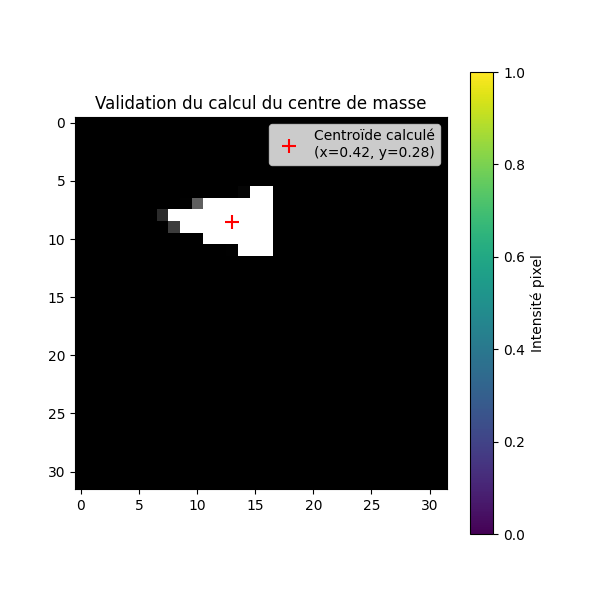

In [71]:
import torch
import matplotlib.pyplot as plt

def test_and_visualize_centroid():
    
    # 3. Calculer le centroïde avec ta fonction
    centroid = get_centroid(masks_diff) # Devrait être proche de [0.78, 0.23]
    cx, cy = centroid[0].tolist()
    
    # 4. Affichage
    plt.figure(figsize=(6, 6))
    plt.imshow(masks_diff[0, 0].cpu(), cmap='gray', origin='upper')
    
    # On replace le centroïde sur l'image (dénormalisation pour l'affichage)
    plt.scatter(cx * (32-1), cy * (32-1), color='red', s=100, marker='+', 
                label=f'Centroïde calculé\n(x={cx:.2f}, y={cy:.2f})')
    
    plt.title("Validation du calcul du centre de masse")
    plt.legend()
    plt.colorbar(label="Intensité pixel")
    plt.show()

# Lancer le test
test_and_visualize_centroid()

In [72]:
get_centroid(masks_diff) 

tensor([[0.4201, 0.2758],
        [0.3082, 0.5385],
        [0.4230, 0.4806],
        ...,
        [0.2218, 0.4670],
        [0.2592, 0.3617],
        [0.7706, 0.6030]])